In [17]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

def compute_sigma(N, ds, n_pml, sigma_max, m_order):
    sig = np.zeros(N)
    for i in range(N):
        dist_left = (n_pml - i) * ds
        dist_right = (i - (N - 1 - n_pml)) * ds
        if dist_left > 0:
            sig[i] = sigma_max * (dist_left / (n_pml * ds))**m_order
        elif dist_right > 0:
            sig[i] = sigma_max * (dist_right / (n_pml * ds))**m_order
    return sig

# --- parâmetros físicos ---
eps = 8.854187817e-12  # Vacuum permittivity (F/m)
mu = 4 * np.pi * 1e-7  # Vacuum permeability (H/m)
vp = 1 / np.sqrt(eps * mu)

# --- domínio ---
Nx = Ny = 200    
dx = dy = 1e-3       
dt = 0.9 / (vp * np.sqrt(1/dx**2 + 1/dy**2))
Nt = 800         
L = Nx * dx
T = Nt * dt

# --- PML ----
npml = 30               
m = 3                   
R_err = 1e-6         
eta = np.sqrt(mu / eps)
d_pml = npml * dx
sig_max = -(m + 1) * np.log(R_err) / (2 * eta * d_pml)

# Declara os campos
Ez = np.zeros((Nx, Ny))
Hx = np.zeros((Nx, Ny))
Hy = np.zeros((Nx, Ny))

grid_x_Ez = np.linspace(0, L, Nx + 1)
grid_y_Ez = np.linspace(0, L, Ny + 1)
grid_t_Ez = np.linspace(0, T, Nt + 1)

# CPML
psi_hxy = np.zeros((Nx, Ny - 1))
psi_hyx = np.zeros((Nx - 1, Ny))
psi_ezx = np.zeros((Nx - 2, Ny - 2))
psi_ezy = np.zeros((Nx - 2, Ny - 2))

sig_x_1D = compute_sigma(Nx, dx, npml, sig_max, m)
sig_y_1D = compute_sigma(Ny, dy, npml, sig_max, m)
sig_x, sig_y = np.meshgrid(sig_x_1D, sig_y_1D, indexing='ij')

b_x = np.exp(-sig_x * dt / eps)
c_x = b_x - 1.0
b_y = np.exp(-sig_y * dt / eps)
c_y = b_y - 1.0

# valores do tempo para salvar os snapshots e montar os heatmaps
n_snapshots = np.linspace(100, 240, 6, dtype=int)
Ez_snapshots = []

# ponta de prova
px, py = Nx // 2 + 50, Ny // 2 + 0
probe = []

for n in range(Nt):
    # atualiza Hx
    dEz_y = (Ez[:, 1:] - Ez[:, :-1]) / dy
    psi_hxy = b_y[:, :-1] * psi_hxy + c_y[:, :-1] * dEz_y
    Hx[:, :-1] -= (dt / mu) * (dEz_y + psi_hxy)

    # atualiza Hy
    dEz_x = (Ez[1:, :] - Ez[:-1, :]) / dx
    psi_hyx = b_x[:-1, :] * psi_hyx + c_x[:-1, :] * dEz_x
    Hy[:-1, :] += (dt / mu) * (dEz_x + psi_hyx)

    # atualiza Ez
    dHy_x = (Hy[1:-1, 1:-1] - Hy[:-2, 1:-1]) / dx
    dHx_y = (Hx[1:-1, 1:-1] - Hx[1:-1, :-2]) / dy
    psi_ezx = b_x[1:-1, 1:-1] * psi_ezx + c_x[1:-1, 1:-1] * dHy_x
    psi_ezy = b_y[1:-1, 1:-1] * psi_ezy + c_y[1:-1, 1:-1] * dHx_y
    Ez[1:-1, 1:-1] += (dt / eps) * ((dHy_x + psi_ezx) - (dHx_y + psi_ezy))

    # fonte
    Ez[Nx//2,Ny//2] += np.exp(-0.5 * ((n * dt - (40 * dt)) / (5 * dt))**2)

    # ponta de prova
    probe.append(Ez[px, py]) 

    # salva para os snapshots
    if n in n_snapshots:
        Ez_snapshots.append(Ez.copy())

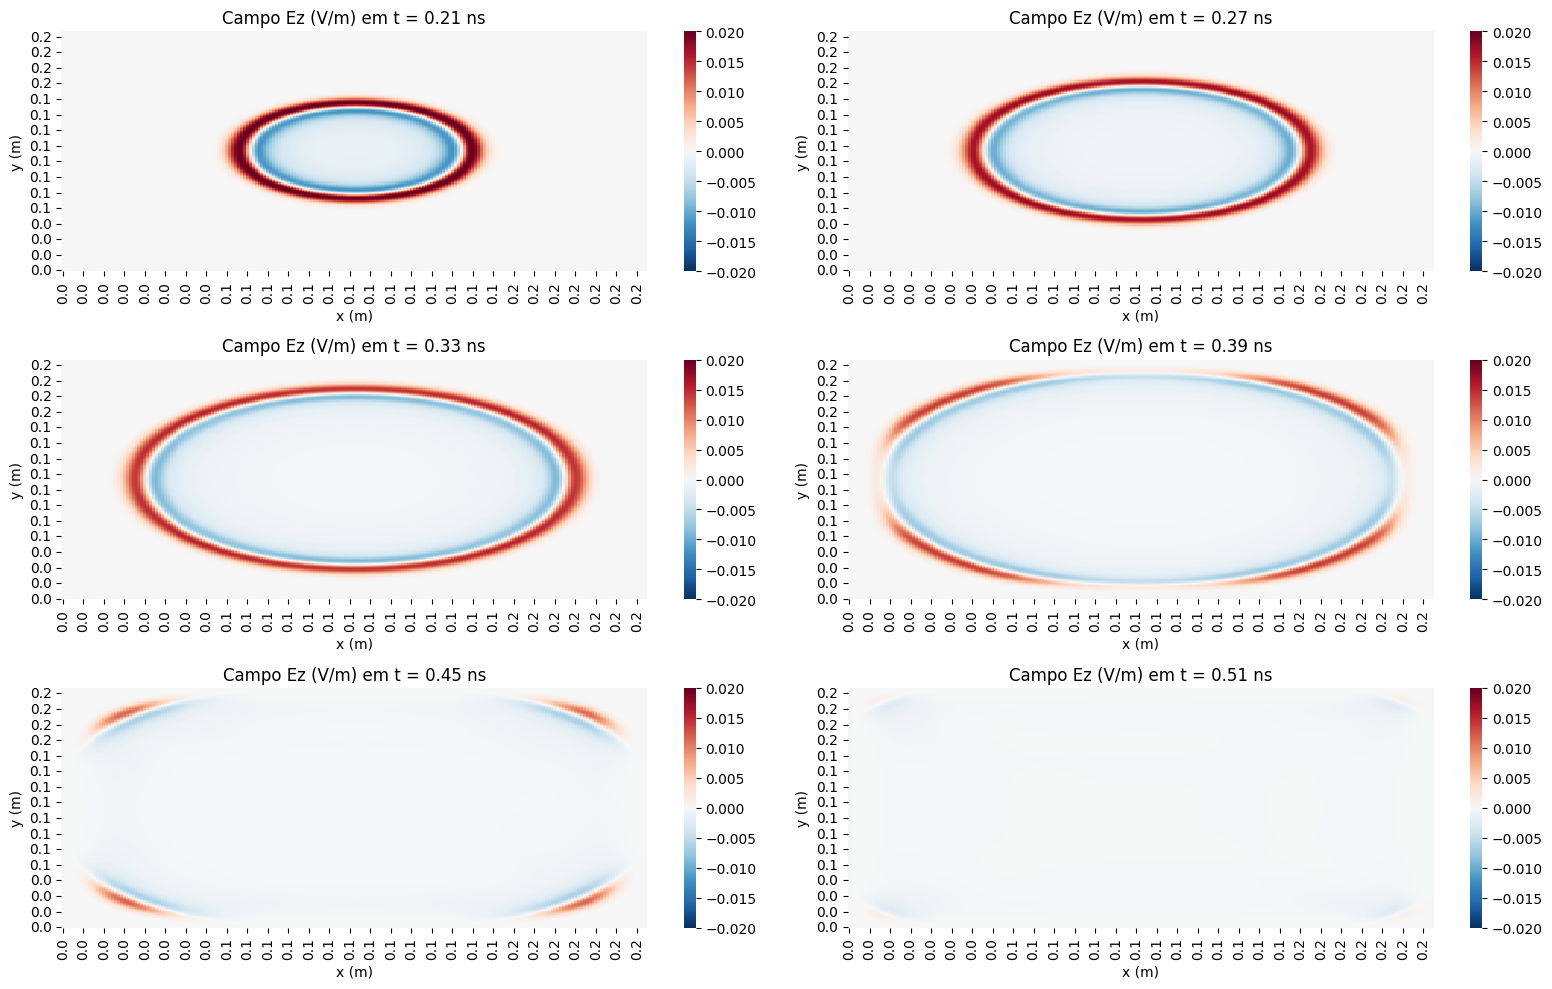

In [18]:
fig, axes = plt.subplots(3, 2, figsize=(16, 10))

for i, ax in enumerate(axes.flat):
    sns.heatmap(Ez_snapshots[i].T, ax=ax, annot=False, cmap='RdBu_r',vmax=0.02,vmin=-0.02,center=0)
    ax.set_xlabel("x (m)")
    ax.set_ylabel("y (m)")
    ax.set_title(f"Campo Ez (V/m) em t = {n_snapshots[i]*dt*1e9:.2f} ns")

    ticks_x = ax.get_xticks()
    labels_x = [f'{float(label.get_text()) * dx * 1:.1f}' for label in ax.get_xticklabels()]
    ax.set_xticklabels(labels_x)

    ticks_y = ax.get_yticks()
    labels_y = [f'{float(label.get_text()) * dy * 1:.1f}' for label in ax.get_yticklabels()]
    ax.set_yticklabels(labels_y)

    ax.invert_yaxis()

plt.tight_layout()
plt.show()

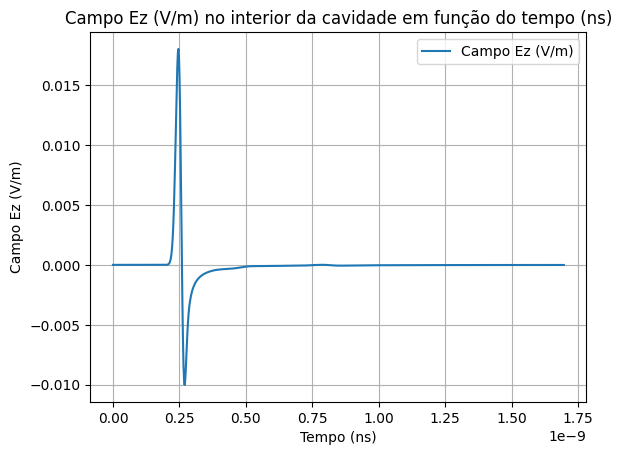

In [19]:
# plt.plot(grid_t_Ez[Nt//2:-2] * 1e9, probe[Nt//2:], label="Campo Ez (V/m)")
plt.plot(grid_t_Ez[:-1], probe[:], label="Campo Ez (V/m)")
plt.title(fr"Campo Ez (V/m) no interior da cavidade em função do tempo (ns)")
plt.xlabel("Tempo (ns)")
plt.ylabel("Campo Ez (V/m)")
plt.grid()
plt.legend()

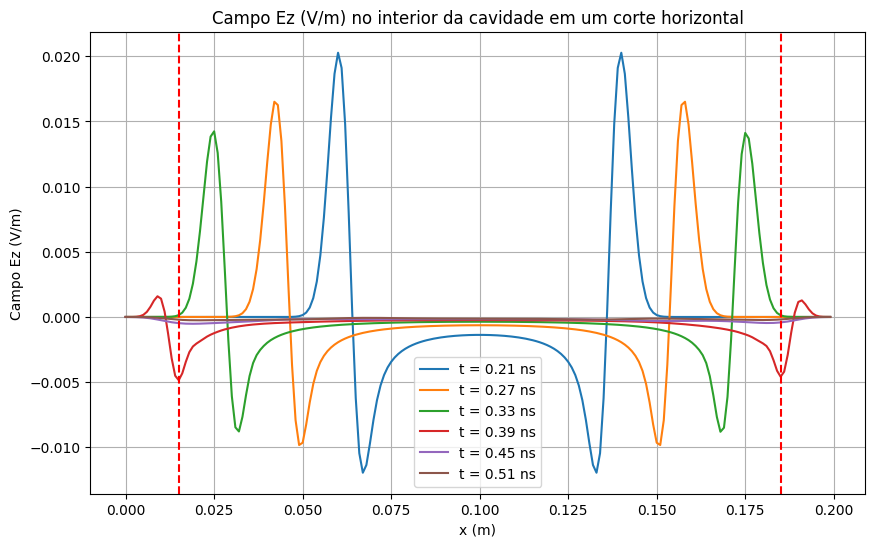

In [20]:
plt.figure(figsize=(10, 6))
plt.title(fr"Campo Ez (V/m) no interior da cavidade em um corte horizontal")
for n in range(len(Ez_snapshots)):
    plt.plot(grid_x_Ez[:-1], Ez_snapshots[n][:, Ny//2], label=f"t = {n_snapshots[n] * dt * 1e9:.2f} ns")
plt.axvline(x=(npml//2)*dx, color='r', linestyle='--')
plt.axvline(x=(Nx - (npml//2))*dx, color='r', linestyle='--')
plt.xlabel("x (m)")
plt.ylabel("Campo Ez (V/m)")
plt.grid()
plt.legend()

In [21]:
R = np.max(np.abs(probe[(int(4e-9 / dt)):])) / np.max(np.abs(probe[:]))
print(R)

ValueError: zero-size array to reduction operation maximum which has no identity